状态形状: (8,)
动作数量: 4
初始状态: [0.001 1.417 0.062 0.249 -0.001 -0.014 0.000 0.000]
动作: 0
下一状态: [0.001 1.422 0.062 0.224 -0.001 -0.014 0.000 0.000]
获得的奖励: 1.9140130099486612
 episode是否终止: False
信息: {}
所有测试通过！
所有测试通过！
所有测试通过！
所有测试通过！
Episode 100 | 最近100个episode的平均得分: -172.18
Episode 200 | 最近100个episode的平均得分: -110.39
Episode 300 | 最近100个episode的平均得分: -33.680
Episode 400 | 最近100个episode的平均得分: -12.89
Episode 500 | 最近100个episode的平均得分: 99.712
Episode 600 | 最近100个episode的平均得分: 190.32
Episode 630 | 最近100个episode的平均得分: 200.17

环境在630个episode内被解决!

总运行时间: 1090.56秒 (18.18分钟)


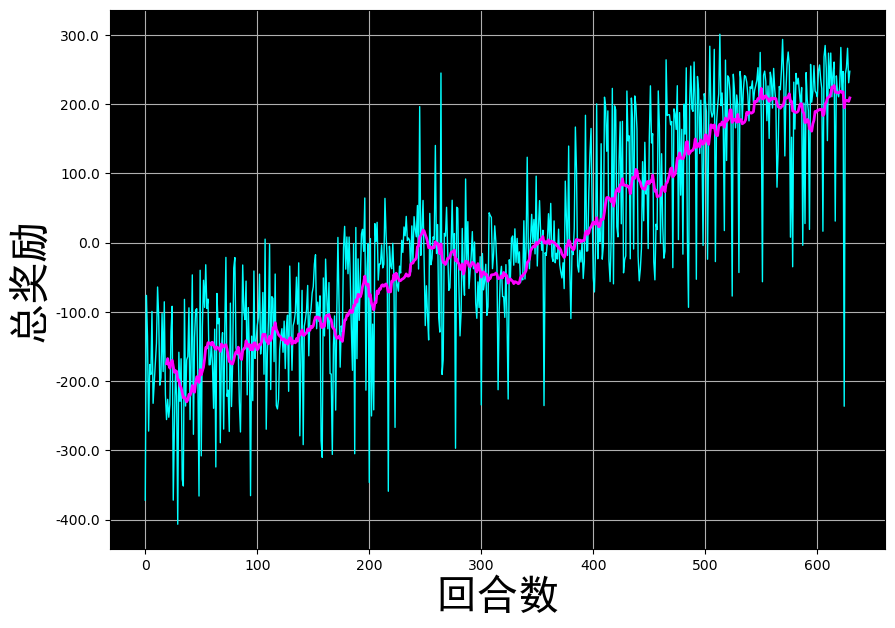

In [1]:
import time
from collections import deque, namedtuple

import gymnasium as gym
import numpy as np
import PIL.Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import utils

# 设置随机种子
torch.manual_seed(utils.SEED)
np.random.seed(utils.SEED)

MEMORY_SIZE = 100_000     # 记忆缓冲区大小
GAMMA = 0.995             # 折扣因子
ALPHA = 1e-3              # 学习率
NUM_STEPS_FOR_UPDATE = 4  # 每C步执行一次学习更新

# 创建环境时指定渲染模式为rgb_array
env = gym.make('LunarLander-v3', render_mode='rgb_array')

# 直接渲染，无需指定mode参数
env.reset()
PIL.Image.fromarray(env.render())

state_size = env.observation_space.shape
num_actions = env.action_space.n

print('状态形状:', state_size)
print('动作数量:', num_actions)

# 重置环境并获取初始状态（注意：Gymnasium的reset返回(state, info)元组）
initial_state, _ = env.reset()

# 选择一个动作
action = 0

# 用给定的动作运行环境动态的单个时间步
next_state, reward, done, truncated, info = env.step(action)
# 合并done和truncated（如果需要）
done = done or truncated

with np.printoptions(formatter={'float': '{:.3f}'.format}):
    print("初始状态:", initial_state)
    print("动作:", action)
    print("下一状态:", next_state)
    print("获得的奖励:", reward)
    print(" episode是否终止:", done)
    print("信息:", info)


# 创建Q网络
class QNetwork(nn.Module):
    def __init__(self, state_size, num_actions):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size[0], 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, num_actions)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# 初始化Q网络和目标Q网络
q_network = QNetwork(state_size, num_actions)
target_q_network = QNetwork(state_size, num_actions)

# 复制Q网络权重到目标Q网络
target_q_network.load_state_dict(q_network.state_dict())
target_q_network.eval()  # 目标网络设为评估模式

# 定义优化器
optimizer = optim.Adam(q_network.parameters(), lr=ALPHA)

# 单元测试
from public_tests import *

test_network_pytorch(q_network)
test_network_pytorch(target_q_network)
test_optimizer_pytorch(optimizer, ALPHA)

# 用命名元组存储经验
Experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

# 计算损失的函数
def compute_loss(experiences, gamma, q_network, target_q_network):
    """
    计算损失
    
    参数:
      experiences: (元组) 包含["state", "action", "reward", "next_state", "done"]的命名元组
      gamma: (float) 折扣因子
      q_network: (PyTorch模型) 预测q值的模型
      target_q_network: (PyTorch模型) 预测目标值的模型
          
    返回:
      loss: (PyTorch张量) y目标与Q(s,a)值之间的均方误差
    """
    
    # 解包小批量经验元组
    states, actions, rewards, next_states, done_vals = experiences
    
    # 转换为PyTorch张量
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)  # 增加维度以便gather操作
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    done_vals = torch.FloatTensor(done_vals)
    
    # 计算max Q^(s,a)
    with torch.no_grad():  # 目标网络不计算梯度
        max_qsa = target_q_network(next_states).max(1)[0]
    
    # 设置y = R如果episode终止，否则y = R + γ max Q^(s,a)
    y_targets = rewards + (1 - done_vals) * gamma * max_qsa
    
    # 获取q值
    q_values = q_network(states)
    q_values = q_values.gather(1, actions).squeeze(1)  # 选择对应动作的Q值
    
    # 计算损失
    loss = F.mse_loss(q_values, y_targets)
    
    return loss

# 单元测试
test_compute_loss_pytorch(compute_loss)

def agent_learn(experiences, gamma):
    """
    更新Q网络的权重
    
    参数:
      experiences: (元组) 包含["state", "action", "reward", "next_state", "done"]的命名元组
      gamma: (float) 折扣因子
    """
    
    # 计算损失
    loss = compute_loss(experiences, gamma, q_network, target_q_network)
    
    # 清零梯度
    optimizer.zero_grad()
    
    # 反向传播
    loss.backward()
    
    # 更新权重
    optimizer.step()
    
    # 更新目标Q网络的权重
    utils.update_target_network_pytorch(q_network, target_q_network)

start = time.time()

num_episodes = 2000
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # 用于平均的总点数
epsilon = 1.0     # ε-贪婪策略的初始ε值

# 创建容量为N的记忆缓冲区D
memory_buffer = deque(maxlen=MEMORY_SIZE)

for i in range(num_episodes):
    
    # 重置环境到初始状态并获取初始状态（Gymnasium返回(state, info)）
    state, _ = env.reset()
    total_points = 0
    
    for t in range(max_num_timesteps):
        
        # 从当前状态S使用ε-贪婪策略选择动作A
        state_tensor = torch.FloatTensor(state).unsqueeze(0)  # 状态需要符合q_network的输入形状
        with torch.no_grad():
            q_values = q_network(state_tensor)
        action = utils.get_action(q_values.numpy(), epsilon)
        
        # 执行动作A并接收奖励R和下一状态S'（Gymnasium的step返回5个值）
        next_state, reward, done, truncated, _ = env.step(action)
        # 合并done和truncated
        done = done or truncated
        
        # 将经验元组(S,A,R,S')存储在记忆缓冲区中
        memory_buffer.append(Experience(state, action, reward, next_state, done))
        
        # 仅每NUM_STEPS_FOR_UPDATE时间步更新网络
        update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
        
        if update:
            # 从D中随机采样小批量经验元组(S,A,R,S')
            experiences = utils.get_experiences(memory_buffer)
            
            # 设置y目标，执行梯度下降步骤，并更新网络权重
            agent_learn(experiences, GAMMA)
        
        state = next_state.copy()
        total_points += reward
        
        if done:
            break
            
    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:]) if i >= num_p_av else np.mean(total_point_history)
    
    # 更新ε值
    epsilon = utils.get_new_eps(epsilon)

    print(f"\rEpisode {i+1} | 最近{num_p_av}个episode的平均得分: {av_latest_points:.2f}", end="")

    if (i+1) % num_p_av == 0:
        print(f"\rEpisode {i+1} | 最近{num_p_av}个episode的平均得分: {av_latest_points:.2f}")

    # 如果最近100个episode的平均得分为200分，我们认为环境被解决了
    if av_latest_points >= 200.0 and i >= num_p_av:
        print(f"\n\n环境在{i+1}个episode内被解决!")
        torch.save(q_network.state_dict(), 'lunar_lander_model.pth')
        break
        
tot_time = time.time() - start

print(f"\n总运行时间: {tot_time:.2f}秒 ({(tot_time/60):.2f}分钟)")

# 绘制得分历史
utils.plot_history(total_point_history)

# 抑制imageio的警告
import logging
logging.getLogger().setLevel(logging.ERROR)

filename = "./videos/lunar_lander.mp4"

utils.create_video_pytorch(filename, env, q_network)
utils.embed_mp4(filename)